# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

## 1) Текстовое описание набора данных

Набор данных по исследованию качества воздуха - https://archive.ics.uci.edu/dataset/360/air+quality

Набор содержит почасовые данные, полученные от комбинированного газоанализатора, установленного в итальянском городе вблизи автомобильной магистрали. Данные записывались с Марта 2004 по февраль 2005 (один год).  

Датасет состоит из 2-х файлов одинаковых данных в формате .csv и .xlsx 

Каждый файл содержит следующие колонки:
- Date	дата в формате ДЕНЬ-МЕСЯЦ-ГОД Набор данных содержит данные с интервалом измерения в один час.
- Time	время в формате ЧАСЫ:МИНУТЫ:СЕКУНДЫ.
- CO(GT)	концентрация СО mg/m^3
- PT08.S1(CO)	концентрация СО mg/m^3 усредненная за час 
- NMHC(GT)	максимальная концентрация паров гидрокарбонатов усредненная за час  microg/m^3 
- C6H6(GT)	максимальная концентрация паров бензина усредненная за час  microg/m^3
- PT08.S2(NMHC)	концентрация паров гидрокарбонатов усредненная за час  microg/m^3
- NOx(GT)	максимальная концентрация оксидов азота усредненная за час  microg/m^3
- PT08.S3(NOx)	концентрация оксидов азота усредненная за час  microg/m^3
- NO2(GT)	максимальная концентрация двуокиси азота усредненная за час  microg/m^3
- PT08.S4(NO2)	концентрация двуокиси азота усредненная за час  microg/m^3
- PT08.S5(O3)	концентрация озона усредненная за час  microg/m^3
- T	температура в градусах Цельсия
- RH	относительная влажность в %.
- AH	абсолютная влажность в %.
- Category категория качества воздуха - Good/Bad


# Импорт библиотек


In [190]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
%matplotlib inline 
sns.set(style="ticks")

# Загрузка данных



In [191]:
# 
data = pd.read_csv('air+quality/2.csv', sep=";")
data = data.drop(columns=['Unnamed: 16'])

# 2) Основные характеристики датасета

In [192]:
# Первые 5 строк датасета
data.head()

,Date,Time,COGT,PT08S1CO,NMHCGT,C6H6GT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,PT08S5O3,T,RH,AH,Category
0,10.03.2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268,13.6,48.9,0.7578,Bad
1,10.03.2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972,13.3,47.7,0.7255,Bad
2,10.03.2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074,11.9,54.0,0.7502,Bad
3,10.03.2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203,11.0,60.0,0.7867,Bad
4,10.03.2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110,11.2,59.6,0.7888,Good


In [193]:
# Размер датасета - 9357 строк, 16 колонок
data.shape

(9357, 16)

In [194]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 9357


In [195]:
# Список колонок
data.columns

Index(['Date', 'Time', 'COGT', 'PT08S1CO', 'NMHCGT', 'C6H6GT', 'PT08S2NMHC',
       'NOxGT', 'PT08S3NOx', 'NO2GT', 'PT08S4NO2', 'PT08S5O3', 'T', 'RH', 'AH',
       'Category'],
      dtype='object')

In [196]:
# Список колонок с типами данных
data.dtypes

Date           object
Time           object
COGT          float64
PT08S1CO      float64
NMHCGT        float64
C6H6GT        float64
PT08S2NMHC    float64
NOxGT         float64
PT08S3NOx     float64
NO2GT         float64
PT08S4NO2     float64
PT08S5O3        int64
T             float64
RH            float64
AH            float64
Category       object
dtype: object

In [197]:
# Проверим наличие пустых значений
hcols_with_na = [c for c in data.columns if data[c].isnull().sum() > 0]
hcols_with_na

['COGT',
 'PT08S1CO',
 'NMHCGT',
 'PT08S2NMHC',
 'NOxGT',
 'PT08S3NOx',
 'NO2GT',
 'PT08S4NO2',
 'T',
 'AH']

In [198]:
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Date - 0
Time - 0
COGT - 1592
PT08S1CO - 331
NMHCGT - 8139
C6H6GT - 0
PT08S2NMHC - 366
NOxGT - 1595
PT08S3NOx - 366
NO2GT - 1598
PT08S4NO2 - 366
PT08S5O3 - 0
T - 366
RH - 0
AH - 366
Category - 0


In [199]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка COGT. Тип данных float64. Количество пустых значений 1592, 17.01%.
Колонка PT08S1CO. Тип данных float64. Количество пустых значений 331, 3.54%.
Колонка NMHCGT. Тип данных float64. Количество пустых значений 8139, 86.98%.
Колонка PT08S2NMHC. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка NOxGT. Тип данных float64. Количество пустых значений 1595, 17.05%.
Колонка PT08S3NOx. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка NO2GT. Тип данных float64. Количество пустых значений 1598, 17.08%.
Колонка PT08S4NO2. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка T. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка AH. Тип данных float64. Количество пустых значений 366, 3.91%.


In [200]:
# Колонки для которых удаляются пропуски
hcols_with_na_temp = ['COGT', 'NMHCGT', 'NOxGT', 'NO2GT']
data_drop = data.drop(hcols_with_na_temp, axis=1)
data_drop.shape

(9357, 12)

In [201]:
# Колонки с пропусками после удаления
hcols_with_na = [c for c in data_drop.columns if data_drop[c].isnull().sum() > 0]
hcols_with_na

['PT08S1CO', 'PT08S2NMHC', 'PT08S3NOx', 'PT08S4NO2', 'T', 'AH']

In [202]:
#Удаление строк с пропусками
data_drop = data_drop.dropna(axis=0, how='any')
data_drop.shape

(8991, 12)

# 3) Разница между распределениями до и после устранения пропусков

In [203]:
def plot_hist_diff(old_ds, new_ds, cols):
    """
    Разница между распределениями до и после устранения пропусков
    """
    for c in cols:   
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.title.set_text('Поле - ' + str(c))
        old_ds[c].hist(bins=50, ax=ax, density=True, color='green')
        new_ds[c].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.5)
        plt.show()

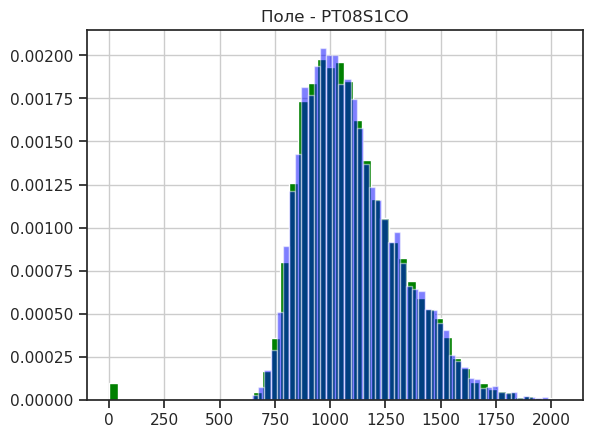

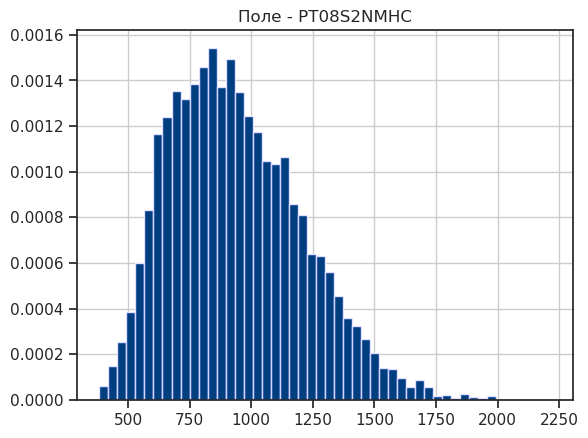

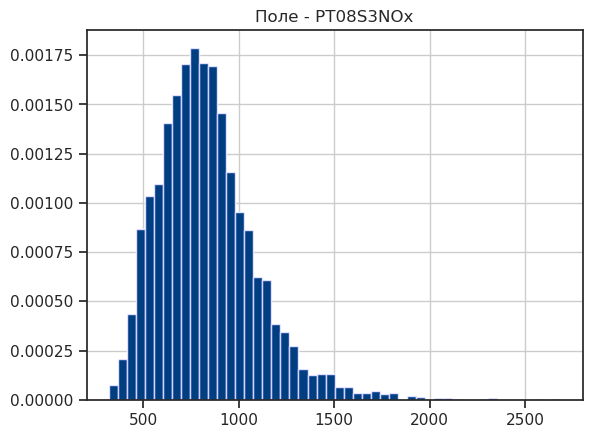

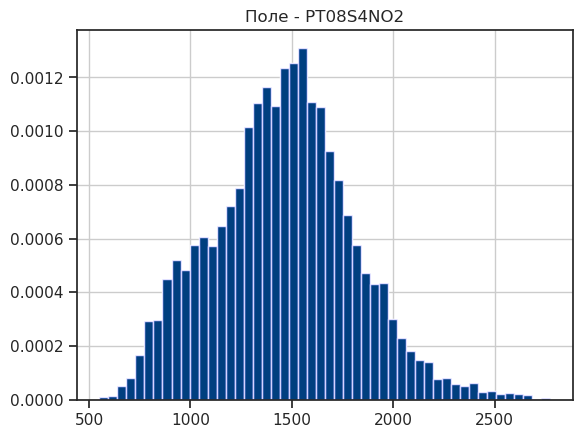

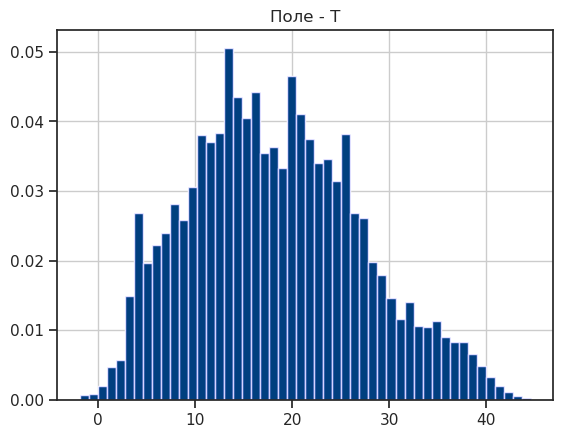

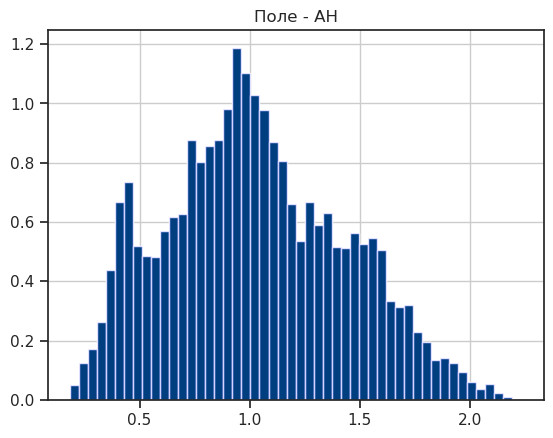

In [204]:
plot_hist_diff(data, data_drop, hcols_with_na)

#"Внедрение значений" - импьютация (imputation)

In [205]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка COGT. Тип данных float64. Количество пустых значений 1592, 17.01%.
Колонка PT08S1CO. Тип данных float64. Количество пустых значений 331, 3.54%.
Колонка NMHCGT. Тип данных float64. Количество пустых значений 8139, 86.98%.
Колонка PT08S2NMHC. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка NOxGT. Тип данных float64. Количество пустых значений 1595, 17.05%.
Колонка PT08S3NOx. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка NO2GT. Тип данных float64. Количество пустых значений 1598, 17.08%.
Колонка PT08S4NO2. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка T. Тип данных float64. Количество пустых значений 366, 3.91%.
Колонка AH. Тип данных float64. Количество пустых значений 366, 3.91%.


In [206]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,COGT,PT08S1CO,NMHCGT,PT08S2NMHC,NOxGT,PT08S3NOx,NO2GT,PT08S4NO2,T,AH
0,2.6,1360.0,150.0,1046.0,166.0,1056.0,113.0,1692.0,13.6,0.7578
1,2.0,1292.0,112.0,955.0,103.0,1174.0,92.0,1559.0,13.3,0.7255
2,2.2,1402.0,88.0,939.0,131.0,1140.0,114.0,1555.0,11.9,0.7502
3,2.2,1376.0,80.0,948.0,172.0,1092.0,122.0,1584.0,11.0,0.7867
4,1.6,1272.0,51.0,836.0,131.0,1205.0,116.0,1490.0,11.2,0.7888
...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.0,NaN,1101.0,472.0,539.0,190.0,1374.0,21.9,0.7568
9353,2.4,1163.0,NaN,1027.0,353.0,604.0,179.0,1264.0,24.3,0.7119
9354,2.4,1142.0,NaN,1063.0,293.0,603.0,175.0,1241.0,26.9,0.6406
9355,2.1,1003.0,NaN,961.0,235.0,702.0,156.0,1041.0,28.3,0.5139


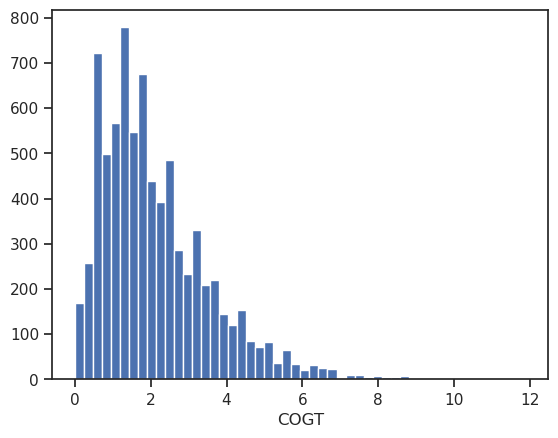

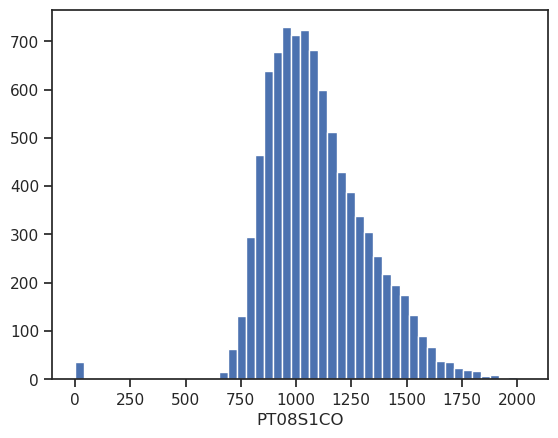

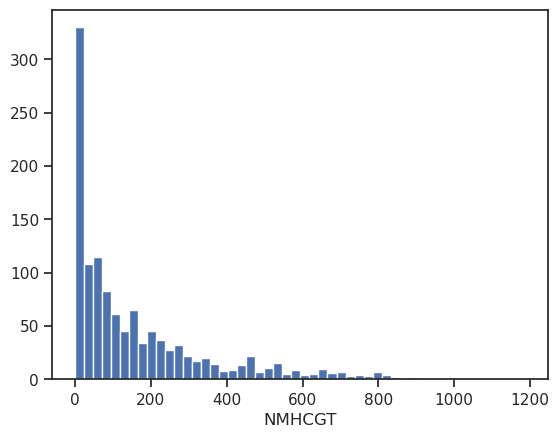

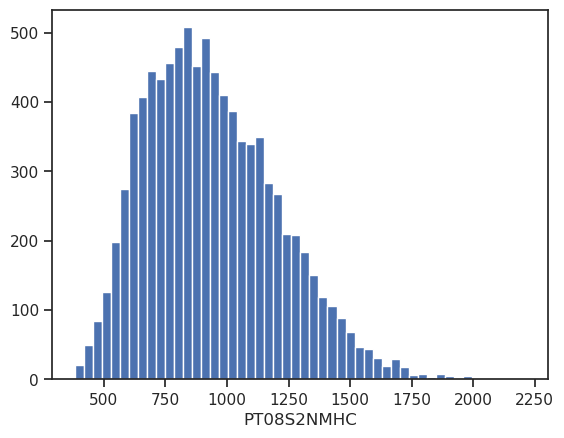

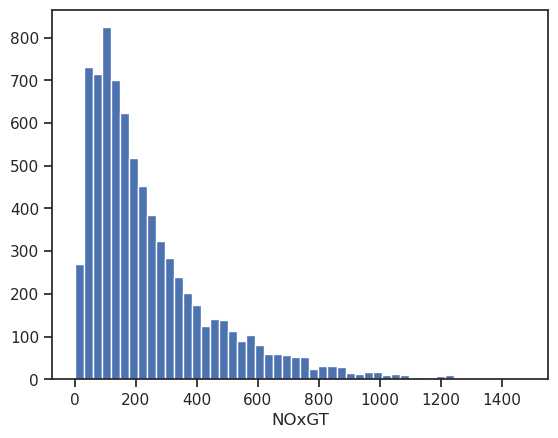

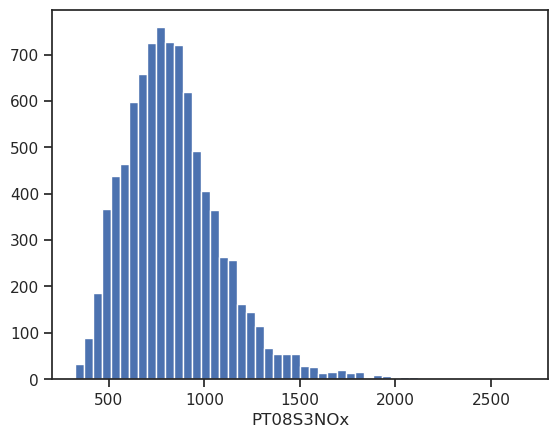

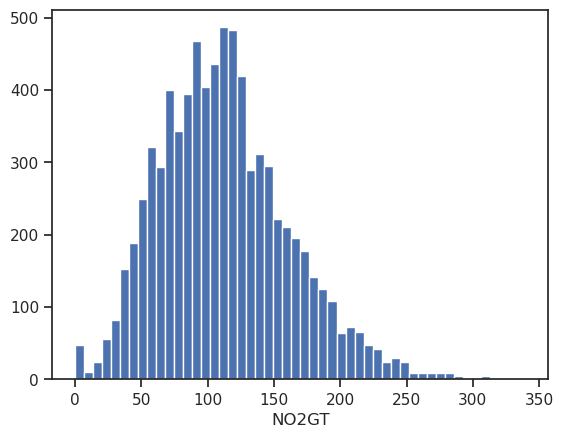

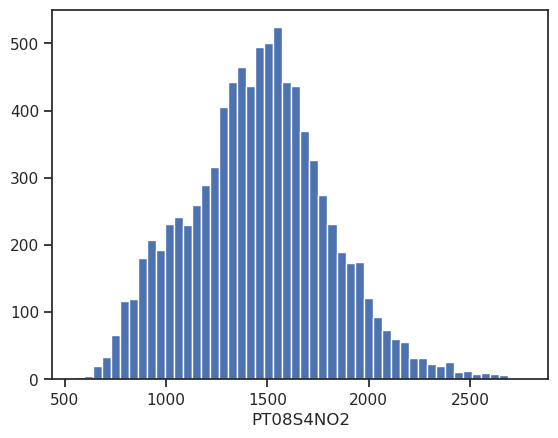

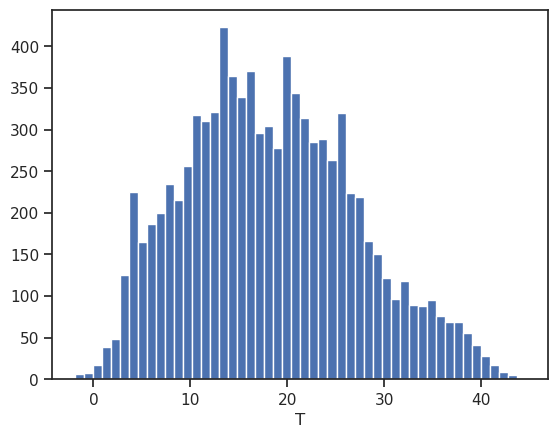

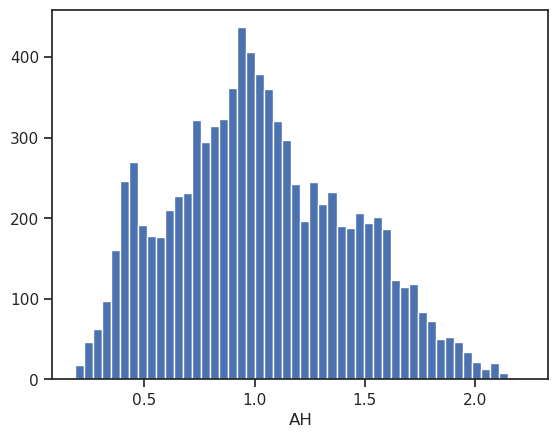

In [207]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [208]:
data_num_PT08S1CO = data_num[['PT08S1CO']]
data_num_PT08S1CO

,PT08S1CO
0,1360.0
1,1292.0
2,1402.0
3,1376.0
4,1272.0
...,...
9352,1314.0
9353,1163.0
9354,1142.0
9355,1003.0


In [209]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator( )
mask_missing_values_only = indicator.fit_transform(data_num_PT08S1CO)
mask_missing_values_only

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(9357, 1))

In [210]:
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_PT08S1CO)
    return data_num_imp[mask_missing_values_only]

In [211]:
strategies[0], test_num_impute(strategies[0])

('mean',
 array([1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1095.56835808, 1095.56835808,
        1095.56835808, 1095.56835808, 1

In [212]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062.,
        1062., 1062., 1062., 1062., 1062., 1062., 1062., 1062., 10

In [213]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [214]:
# Более сложная функция, которая позволяет задавать колонку и вид импьютации
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [215]:
data[['PT08S1CO']].describe()

,PT08S1CO
count,9026.000000
mean,1095.568358
std,227.186923
min,0.000000
25%,935.000000
50%,1062.000000
75%,1230.000000
max,2040.000000


In [216]:
test_num_impute_col(data, 'PT08S1CO', strategies[0])

('PT08S1CO',
 'mean',
 331,
 np.float64(1095.5683580766674),
 np.float64(1095.5683580766674))

In [217]:
test_num_impute_col(data, 'PT08S1CO', strategies[1])

('PT08S1CO', 'median', 331, np.float64(1062.0), np.float64(1062.0))

In [218]:
test_num_impute_col(data, 'PT08S1CO', strategies[2])

('PT08S1CO', 'most_frequent', 331, np.float64(0.0), np.float64(0.0))

In [219]:
#Преобразование категориальных признаков в числовые

In [220]:
from sklearn.preprocessing import OrdinalEncoder

In [221]:
data_oe = data[['Category']]
data_oe.head()

,Category
0,Bad
1,Bad
2,Bad
3,Bad
4,Good


In [222]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['Bad'],
       ['Bad'],
       ['Bad'],
       ...,
       ['Bad'],
       ['Bad'],
       ['Bad']], shape=(9357, 1), dtype=object)

In [223]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(9357, 1))

In [224]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1.])

In [225]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Bad', 'Good'], dtype=object)]

In [226]:
# Масштабирование данных
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

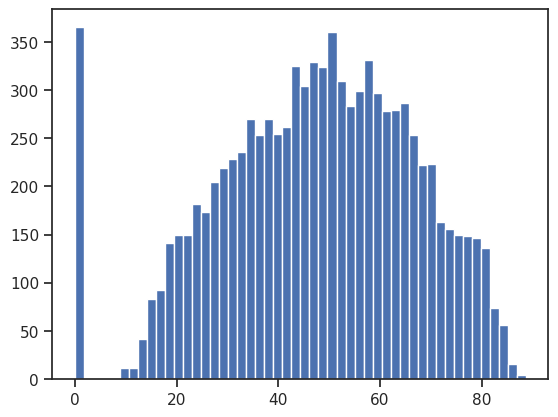

In [227]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['RH']])
plt.hist(data['RH'], 50)
plt.show()

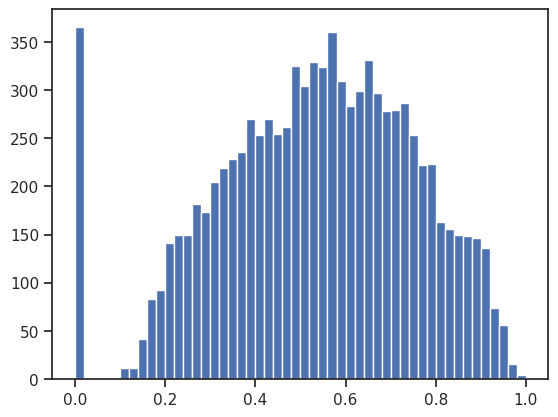

In [228]:
plt.hist(sc1_data, 50)
plt.show()

In [229]:
# Масштабирование данных на основе Z-оценки - StandardScaler

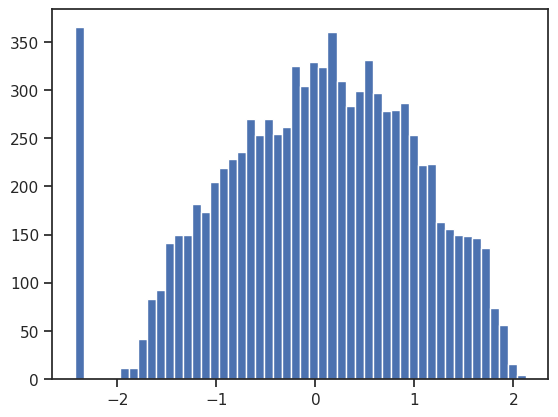

In [230]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['RH']])
plt.hist(sc2_data, 50)
plt.show()